### Scott 10K imshow

#### Visual inspection of the VBM (and SBM?) values we have obtained prior to performing linear spatial regressions

#### Aim is to look with imshow, but with (1) ordered by diagnosis (1,2,3,nm) and 2. Look at data during various parts of the cleaning stages.

#### Prelims: make folder to store pngs (they will be big and need to be generated with HPC), scripts and logs folder too

In [1]:
%%bash

mkdir -p /rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_visualisation/imshow_images
mkdir -p /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow
mkdir -p /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/imshow

#### Create dataframe (in memory) of VBM values ordered by diagnosis and remove data_key

In [1]:
%%file /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_imshow.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.stats import zscore
import os
import sys
from matplotlib import font_manager


font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

orig_df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/no_neuroimaging_data_scott10k_alliedhealth.csv', low_memory = False)

orig_df_essentials = orig_df[['DATA_KEY', 'DIAGNOSIS', 'MWC1T1_PATH']].sort_values(by = 'DIAGNOSIS', ascending = True)
orig_df_essentials.dropna(axis = 0, subset = 'MWC1T1_PATH', inplace = True)
print(orig_df_essentials.head(5))

def my_imshow(right: str, title: str, left = orig_df_essentials):
    '''
    This function aims to grab a dataframe of patient data, and:
    1. Merge this data with diagnosis and whether that scan has an MWC1T1_PATH
    2. Sort patient data in order of diagnosis (CN, MCI, AD, not matched)
    3. Removes data without an MWC1T1_PATH
    4. z-score the brain data
    5. Create an 'imshow'-style graph of the zscored brain data, with a separate colour-coded column for diagnosis
    '''

    #1. Merge this data with diagnosis and whether that scan has an MWC1T1_PATH
    right_path = os.path.join('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping', f"{right}.csv").strip()
    print(right_path)
    if os.path.exists(right_path):
        right_df = pd.read_csv(right_path, low_memory = False)
        merged_df = pd.merge(left = left, right = right_df, how = 'left', on = 'DATA_KEY')
        #2. Sort patient data in order of diagnosis (CN, MCI, AD, not matched)
        merged_df.sort_values(by = 'DIAGNOSIS', ascending = True, inplace = True)
        
        #3. Removes data without an MWC1T1_PATH
        merged_df.dropna(axis = 0, subset = 'MWC1T1_PATH', inplace = True)
        merged_df_diags = merged_df['DIAGNOSIS']
        merged_df.drop(columns = ['DATA_KEY', 'DIAGNOSIS', 'MWC1T1_PATH'], inplace = True)
    
        #4. z-score the brain data
        zscored_merged_df = pd.DataFrame(
            zscore(merged_df, axis=0, nan_policy='omit'),
            columns=merged_df.columns,
            index=merged_df.index)
    
        merged_df_diag_colours = merged_df_diags.map({3: 'red', 2: 'blue', 1: 'green', np.nan: 'black'})
        row_colors = pd.DataFrame({'Diagnosis': merged_df_diag_colours})
    
        #5. Create an 'imshow'-style graph of the zscored brain data, with a separate colour-coded column for diagnosis
        #NB: I am using sns.clustermap here because it achieves what plt.imshow can but it's less finnicky
        
        sns.clustermap(
        zscored_merged_df,
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        row_colors=row_colors,
        col_cluster=False,
        row_cluster=False,
        figsize=(200, 100))

            
    
        plt.suptitle(title, fontsize = 50)
        plt.tight_layout()

        #6. Save the created figure so I can look at is properly later
        file_name = right
        plt.savefig(f'/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_visualisation/imshow_images/{file_name}.png', dpi = 300)
        plt.show()


files_n_titles = [['dropped_unknown_cols_scraped_desikan_stats', 'VBM ROI data (dropped unknown cols, Desikan)'],
                 ['renamed_cols_scraped_desikan_stats', 'VBM ROI data (Desikan)'],
                 ['renamed_cols_scraped_destrieux_stats', 'VBM ROI data (Destrieux)'],
                  ['dropped_unknown_cols_scraped_destrieux_stats', 'VBM ROI data (dropped unknown cols, Destrieux)']]

index = int(sys.argv[1]) - 1

my_imshow(files_n_titles[index][0], files_n_titles[index][1])

Overwriting /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_imshow.py


In [7]:
%%file /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_imshow.sh

#!/bin/bash
#PBS -l walltime=00:10:00
#PBS -l select=1:ncpus=1:mem=50gb
#PBS -N my_imshow
#PBS -J 1-4
#PBS -o /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/imshow
#PBS -e /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/imshow

mkdir -p /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/imshow
module load tools/prod
source /rds/general/user/sk4724/home/venv_1/bin/activate

python /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_imshow.py ${PBS_ARRAY_INDEX}

Overwriting /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_imshow.sh


In [2]:
%%bash

chmod -Rf 775 /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_imshow.*
# export PBS_ARRAY_INDEX=1; /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_imshow.sh 
qsub /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_imshow.sh

2575579[].pbs-7


## A bit of code to see whether I should exclude the brain stem or not from the final regression. I then realised I should exclude the brainstem because while the atlases ignore the tegmentu, they include the pons in their brainstem ROI. 

['DATA_KEY', 'Brain-Stem']


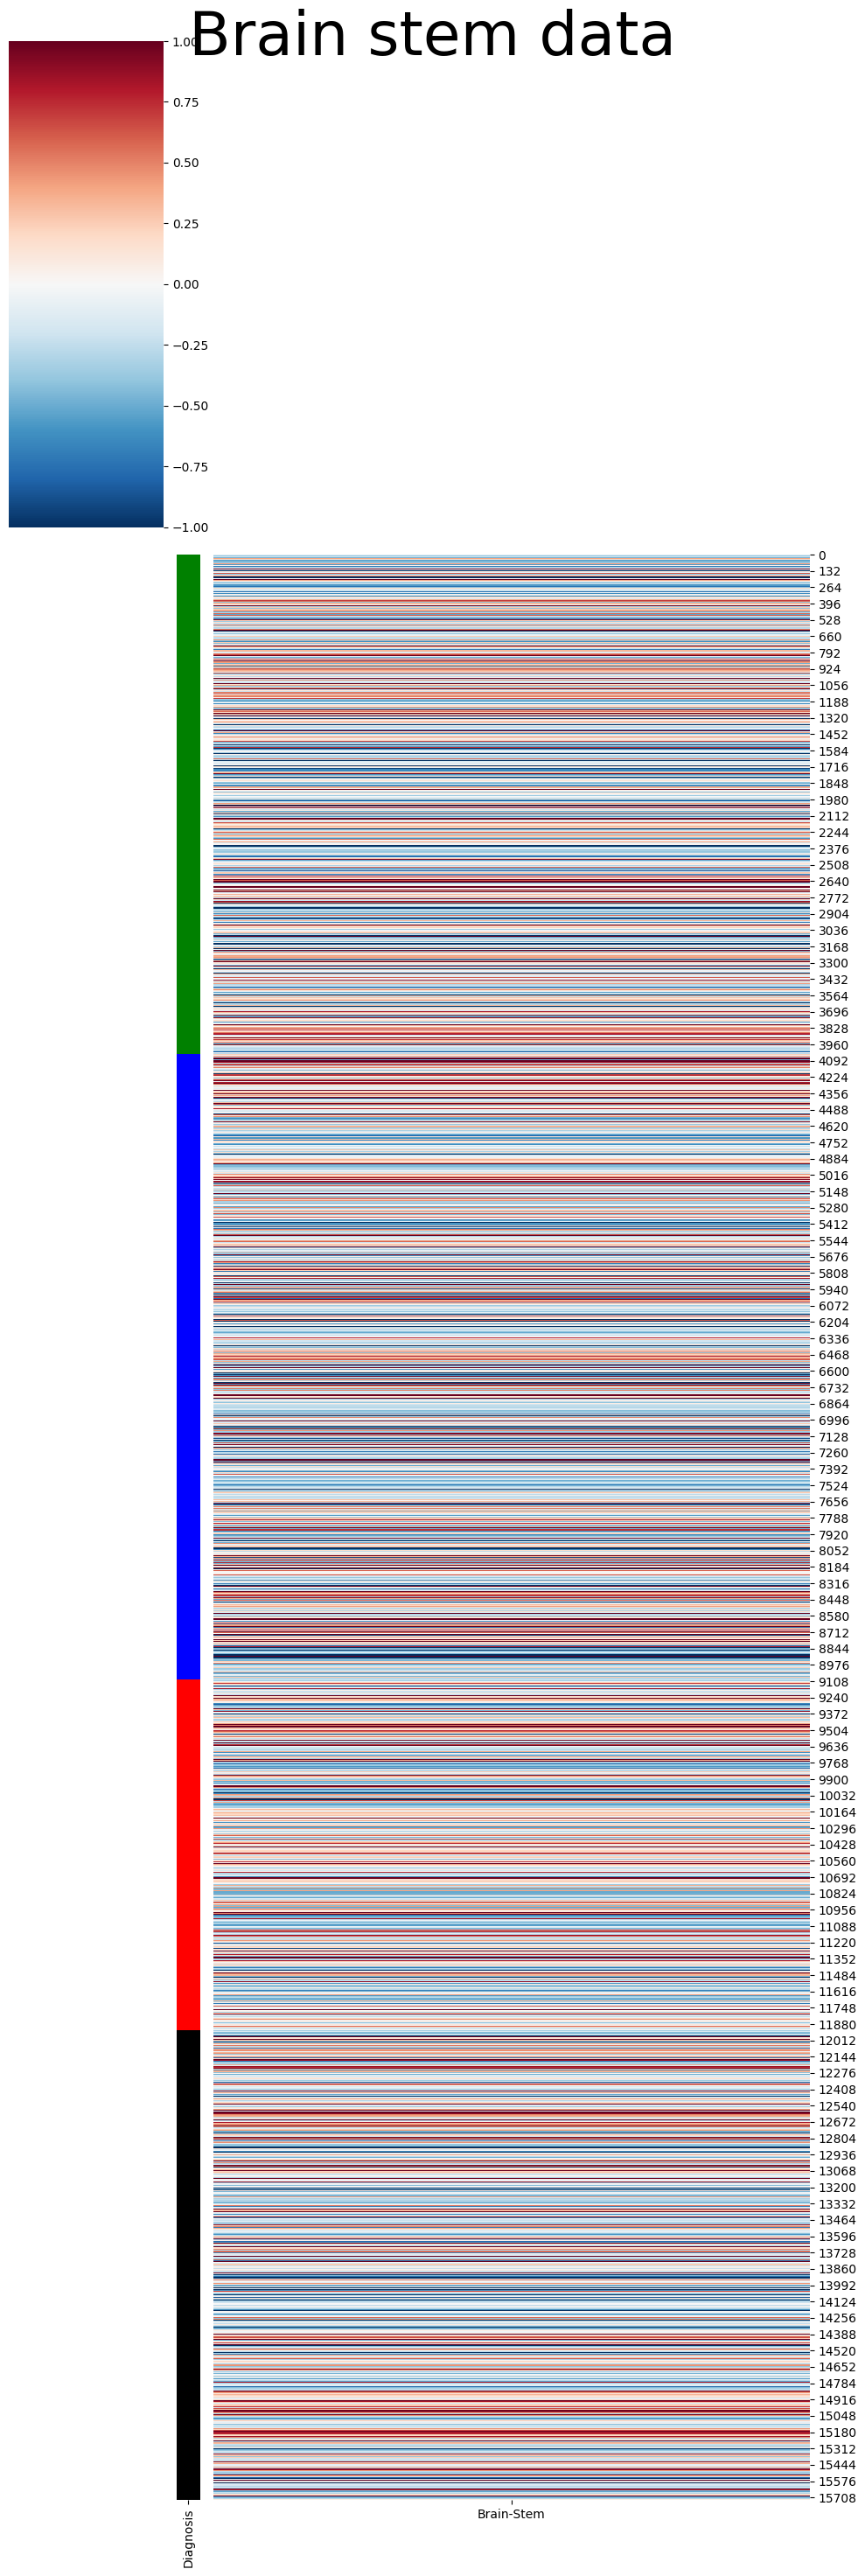

In [3]:
import pandas as pd
import os
import seaborn as sns
import numpy as np
import scipy
from scipy.stats import zscore
import matplotlib.pyplot as plt
from matplotlib import font_manager


font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

orig_df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/no_neuroimaging_data_scott10k_alliedhealth.csv', low_memory = False)

orig_df_essentials = orig_df[['DATA_KEY', 'DIAGNOSIS', 'MWC1T1_PATH']].sort_values(by = 'DIAGNOSIS', ascending = True)
orig_df_essentials.dropna(axis = 0, subset = 'MWC1T1_PATH', inplace = True)

right_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/dropped_unknown_cols_scraped_destrieux_stats.csv'
if os.path.exists(right_path):
    right_df = pd.read_csv(right_path, low_memory = False)
    right_df_essentials = right_df[['DATA_KEY', 'Brain-Stem']]
    print(right_df_essentials.columns.tolist())

    merged_df = pd.merge(left = orig_df_essentials, right = right_df_essentials, how = 'left', on = 'DATA_KEY')
    #2. Sort patient data in order of diagnosis (CN, MCI, AD, not matched)
    merged_df.sort_values(by = 'DIAGNOSIS', ascending = True, inplace = True)
    
    #3. Removes data without an MWC1T1_PATH
    merged_df.dropna(axis = 0, subset = 'MWC1T1_PATH', inplace = True)
    merged_df_diags = merged_df['DIAGNOSIS']
    merged_df.drop(columns = ['DATA_KEY', 'DIAGNOSIS', 'MWC1T1_PATH'], inplace = True)

    #4. z-score the brain data
    zscored_merged_df = pd.DataFrame(
        zscore(merged_df, axis=0, nan_policy='omit'),
        columns=merged_df.columns,
        index=merged_df.index)

    merged_df_diag_colours = merged_df_diags.map({3: 'red', 2: 'blue', 1: 'green', np.nan: 'black'})
    row_colors = pd.DataFrame({'Diagnosis': merged_df_diag_colours})

    sns.clustermap(
    zscored_merged_df,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    row_colors=row_colors,
    col_cluster=False,
    row_cluster=False,
    figsize=(10, 30))

        
    plt.suptitle('Brain stem data', fontsize = 50)
    plt.tight_layout()
    plt.show()


In [4]:
%%file /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_coeffs_imshow.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.stats import zscore
import os
import sys
from matplotlib import font_manager


font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

orig_df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/no_neuroimaging_data_scott10k_alliedhealth.csv', low_memory = False)

orig_df_essentials = orig_df[['DATA_KEY', 'DIAGNOSIS']].sort_values(by = 'DIAGNOSIS', ascending = True)
print(orig_df_essentials.head(5))

def my_imshow(right: str, title: str, left = orig_df_essentials):
    '''
    This function aims to grab a dataframe of patient data, and:
    1. Merge this data with diagnosis
    2. Sort patient data in order of diagnosis (CN, MCI, AD, not matched)
    3. Removes patient scans with absent data
    4. z-score the brain data
    5. Create an 'imshow'-style graph of the zscored brain data, with a separate colour-coded column for diagnosis
    '''

    #1. Merge this data with diagnosis and whether that scan has an MWC1T1_PATH
    right_path = os.path.join('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping', f"{right}.csv").strip()
    print(right_path)
    if os.path.exists(right_path):
        right_df = pd.read_csv(right_path, low_memory = False)
        merged_df = pd.merge(left = left, right = right_df, how = 'left', on = 'DATA_KEY')
        #2. Sort patient data in order of diagnosis (CN, MCI, AD, not matched)
        merged_df.sort_values(by = 'DIAGNOSIS', ascending = True, inplace = True)

        #3. Removes data without an MWC1T1_PATH
        merged_df.dropna(axis = 0, inplace = True)
        merged_df_diags = merged_df['DIAGNOSIS']
        merged_df.drop(columns = ['DIAGNOSIS', 'DATA_KEY'], inplace = True)

        #4. z-score the brain data
        zscored_merged_df = pd.DataFrame(
            zscore(merged_df, axis=0, nan_policy='omit'),
            columns=merged_df.columns,
            index=merged_df.index)

        print(zscored_merged_df.columns.tolist())

        merged_df_diag_colours = merged_df_diags.map({3: 'red', 2: 'blue', 1: 'green', np.nan: 'black'})
        row_colors = pd.DataFrame({'Diagnosis': merged_df_diag_colours})

        #5. Create an 'imshow'-style graph of the zscored brain data, with a separate colour-coded column for diagnosis
        #NB: I am using sns.clustermap here because it achieves what plt.imshow can but it's less finnicky

        sns.clustermap(
        zscored_merged_df,
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        row_colors=row_colors,
        col_cluster=False,
        row_cluster=False,
        figsize=(40, 30))



        plt.suptitle(title, fontsize = 50)
        plt.tight_layout()

        #6. Save the created figure so I can look at is properly later
        file_name = right
        plt.savefig(f'/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_visualisation/imshow_images/{file_name}.png', dpi = 300)
        plt.show()


files_n_titles = [['desikan_coeffs', 'Desikan'],
                 ['flipped_desikan_coeffs', 'Destrieux'],
                 ['destrieux_coeffs', 'Flipped Desikan'],
                  ['flipped_destrieux_coeffs', 'Flipped Destrieux']]

index = int(sys.argv[1]) - 1

my_imshow(files_n_titles[index][0], files_n_titles[index][1])


Overwriting /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_coeffs_imshow.py


In [6]:
%%file /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_coeffs_imshow.sh

#!/bin/bash
#PBS -l walltime=00:10:00
#PBS -l select=1:ncpus=1:mem=50gb
#PBS -N my_coeff_imshow
#PBS -J 1-4
#PBS -o /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/imshow
#PBS -e /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/imshow

mkdir -p /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/imshow
module load tools/prod
source /rds/general/user/sk4724/home/venv_1/bin/activate

python /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_coeffs_imshow.py ${PBS_ARRAY_INDEX}

Overwriting /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_coeffs_imshow.sh


In [5]:
%%bash

chmod +x /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/*
qsub /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_coeffs_imshow.sh

2575583[].pbs-7


#### Plot SBM cortical thickness and ROI GMVs

In [6]:
%%file /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_sbm_imshow.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.stats import zscore
import os
import sys
from matplotlib import font_manager

df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv', low_memory = False)

ordered_desikan_sbm_roi_gmv_cols = ['DIAGNOSIS', 'Left-Cerebellum-Cortex_aseg_stats', 'Left-Thalamus_aseg_stats', 'Left-Caudate_aseg_stats', 
                            'Left-Putamen_aseg_stats', 'Left-Pallidum_aseg_stats', 'Left-Hippocampus_aseg_stats', 'Left-Amygdala_aseg_stats', 'Left-Accumbens-area_aseg_stats', 
                            'Left-VentralDC_aseg_stats', 'Right-Cerebellum-Cortex_aseg_stats', 'Right-Thalamus_aseg_stats', 'Right-Caudate_aseg_stats', 'Right-Putamen_aseg_stats', 
                            'Right-Pallidum_aseg_stats', 'Right-Hippocampus_aseg_stats', 'Right-Amygdala_aseg_stats', 'Right-Accumbens-area_aseg_stats', 'Right-VentralDC_aseg_stats',
                            'lh_bankssts_volume_aparc_volume_lh', 'lh_caudalanteriorcingulate_volume_aparc_volume_lh', 'lh_caudalmiddlefrontal_volume_aparc_volume_lh',
                            'lh_cuneus_volume_aparc_volume_lh', 'lh_entorhinal_volume_aparc_volume_lh', 'lh_fusiform_volume_aparc_volume_lh', 'lh_inferiorparietal_volume_aparc_volume_lh',
                            'lh_inferiortemporal_volume_aparc_volume_lh', 'lh_isthmuscingulate_volume_aparc_volume_lh', 'lh_lateraloccipital_volume_aparc_volume_lh',
                            'lh_lateralorbitofrontal_volume_aparc_volume_lh', 'lh_lingual_volume_aparc_volume_lh', 'lh_medialorbitofrontal_volume_aparc_volume_lh',
                            'lh_middletemporal_volume_aparc_volume_lh', 'lh_parahippocampal_volume_aparc_volume_lh', 'lh_paracentral_volume_aparc_volume_lh',
                            'lh_parsopercularis_volume_aparc_volume_lh', 'lh_parsorbitalis_volume_aparc_volume_lh', 'lh_parstriangularis_volume_aparc_volume_lh', 'lh_pericalcarine_volume_aparc_volume_lh', 
                            'lh_postcentral_volume_aparc_volume_lh', 'lh_posteriorcingulate_volume_aparc_volume_lh', 'lh_precentral_volume_aparc_volume_lh', 'lh_precuneus_volume_aparc_volume_lh', 
                            'lh_rostralanteriorcingulate_volume_aparc_volume_lh', 'lh_rostralmiddlefrontal_volume_aparc_volume_lh', 'lh_superiorfrontal_volume_aparc_volume_lh',
                            'lh_superiorparietal_volume_aparc_volume_lh', 'lh_superiortemporal_volume_aparc_volume_lh', 'lh_supramarginal_volume_aparc_volume_lh', 
                            'lh_frontalpole_volume_aparc_volume_lh', 'lh_temporalpole_volume_aparc_volume_lh', 'lh_transversetemporal_volume_aparc_volume_lh', 'lh_insula_volume_aparc_volume_lh',
                            'rh_bankssts_volume_aparc_volume_rh', 'rh_caudalanteriorcingulate_volume_aparc_volume_rh', 'rh_caudalmiddlefrontal_volume_aparc_volume_rh', 
                            'rh_cuneus_volume_aparc_volume_rh', 'rh_entorhinal_volume_aparc_volume_rh', 'rh_fusiform_volume_aparc_volume_rh', 'rh_inferiorparietal_volume_aparc_volume_rh', 
                            'rh_inferiortemporal_volume_aparc_volume_rh', 'rh_isthmuscingulate_volume_aparc_volume_rh', 'rh_lateraloccipital_volume_aparc_volume_rh', 
                            'rh_lateralorbitofrontal_volume_aparc_volume_rh', 'rh_lingual_volume_aparc_volume_rh', 'rh_medialorbitofrontal_volume_aparc_volume_rh',
                            'rh_middletemporal_volume_aparc_volume_rh', 'rh_parahippocampal_volume_aparc_volume_rh', 'rh_paracentral_volume_aparc_volume_rh', 'rh_parsopercularis_volume_aparc_volume_rh', 
                            'rh_parsorbitalis_volume_aparc_volume_rh', 'rh_parstriangularis_volume_aparc_volume_rh', 'rh_pericalcarine_volume_aparc_volume_rh', 'rh_postcentral_volume_aparc_volume_rh', 
                            'rh_posteriorcingulate_volume_aparc_volume_rh', 'rh_precentral_volume_aparc_volume_rh', 'rh_precuneus_volume_aparc_volume_rh', 
                            'rh_rostralanteriorcingulate_volume_aparc_volume_rh', 'rh_rostralmiddlefrontal_volume_aparc_volume_rh', 'rh_superiorfrontal_volume_aparc_volume_rh', 
                            'rh_superiorparietal_volume_aparc_volume_rh', 'rh_superiortemporal_volume_aparc_volume_rh', 'rh_supramarginal_volume_aparc_volume_rh',
                            'rh_frontalpole_volume_aparc_volume_rh', 'rh_temporalpole_volume_aparc_volume_rh', 'rh_transversetemporal_volume_aparc_volume_rh', 'rh_insula_volume_aparc_volume_rh']

ordered_desikan_sbm_cort_thick_cols = ['DIAGNOSIS', 'lh_bankssts_thickness_aparc_thickness_lh', 'lh_caudalanteriorcingulate_thickness_aparc_thickness_lh',
                                       'lh_caudalmiddlefrontal_thickness_aparc_thickness_lh', 'lh_cuneus_thickness_aparc_thickness_lh', 'lh_entorhinal_thickness_aparc_thickness_lh', 
                                       'lh_fusiform_thickness_aparc_thickness_lh', 'lh_inferiorparietal_thickness_aparc_thickness_lh', 'lh_inferiortemporal_thickness_aparc_thickness_lh', 
                                       'lh_isthmuscingulate_thickness_aparc_thickness_lh', 'lh_lateraloccipital_thickness_aparc_thickness_lh', 'lh_lateralorbitofrontal_thickness_aparc_thickness_lh', 
                                       'lh_lingual_thickness_aparc_thickness_lh', 'lh_medialorbitofrontal_thickness_aparc_thickness_lh', 'lh_middletemporal_thickness_aparc_thickness_lh', 
                                       'lh_parahippocampal_thickness_aparc_thickness_lh', 'lh_paracentral_thickness_aparc_thickness_lh', 'lh_parsopercularis_thickness_aparc_thickness_lh', 
                                       'lh_parsorbitalis_thickness_aparc_thickness_lh', 'lh_parstriangularis_thickness_aparc_thickness_lh', 'lh_pericalcarine_thickness_aparc_thickness_lh',
                                       'lh_postcentral_thickness_aparc_thickness_lh', 'lh_posteriorcingulate_thickness_aparc_thickness_lh', 'lh_precentral_thickness_aparc_thickness_lh', 
                                       'lh_precuneus_thickness_aparc_thickness_lh', 'lh_rostralanteriorcingulate_thickness_aparc_thickness_lh', 'lh_rostralmiddlefrontal_thickness_aparc_thickness_lh', 
                                       'lh_superiorfrontal_thickness_aparc_thickness_lh', 'lh_superiorparietal_thickness_aparc_thickness_lh', 'lh_superiortemporal_thickness_aparc_thickness_lh', 
                                       'lh_supramarginal_thickness_aparc_thickness_lh', 'lh_frontalpole_thickness_aparc_thickness_lh', 'lh_temporalpole_thickness_aparc_thickness_lh', 
                                       'lh_transversetemporal_thickness_aparc_thickness_lh', 'lh_insula_thickness_aparc_thickness_lh', 
                                       'rh_bankssts_thickness_aparc_thickness_rh', 'rh_caudalanteriorcingulate_thickness_aparc_thickness_rh', 'rh_caudalmiddlefrontal_thickness_aparc_thickness_rh', 
                                       'rh_cuneus_thickness_aparc_thickness_rh', 'rh_entorhinal_thickness_aparc_thickness_rh', 'rh_fusiform_thickness_aparc_thickness_rh', 
                                       'rh_inferiorparietal_thickness_aparc_thickness_rh', 'rh_inferiortemporal_thickness_aparc_thickness_rh', 'rh_isthmuscingulate_thickness_aparc_thickness_rh', 
                                       'rh_lateraloccipital_thickness_aparc_thickness_rh', 'rh_lateralorbitofrontal_thickness_aparc_thickness_rh', 
                                       'rh_lingual_thickness_aparc_thickness_rh', 'rh_medialorbitofrontal_thickness_aparc_thickness_rh', 'rh_middletemporal_thickness_aparc_thickness_rh', 
                                       'rh_parahippocampal_thickness_aparc_thickness_rh', 'rh_paracentral_thickness_aparc_thickness_rh', 'rh_parsopercularis_thickness_aparc_thickness_rh', 
                                       'rh_parsorbitalis_thickness_aparc_thickness_rh', 'rh_parstriangularis_thickness_aparc_thickness_rh', 'rh_pericalcarine_thickness_aparc_thickness_rh', 
                                       'rh_postcentral_thickness_aparc_thickness_rh', 'rh_posteriorcingulate_thickness_aparc_thickness_rh', 'rh_precentral_thickness_aparc_thickness_rh', 
                                       'rh_precuneus_thickness_aparc_thickness_rh', 'rh_rostralanteriorcingulate_thickness_aparc_thickness_rh', 'rh_rostralmiddlefrontal_thickness_aparc_thickness_rh', 
                                       'rh_superiorfrontal_thickness_aparc_thickness_rh', 'rh_superiorparietal_thickness_aparc_thickness_rh', 'rh_superiortemporal_thickness_aparc_thickness_rh', 
                                       'rh_supramarginal_thickness_aparc_thickness_rh', 'rh_frontalpole_thickness_aparc_thickness_rh', 'rh_temporalpole_thickness_aparc_thickness_rh', 
                                       'rh_transversetemporal_thickness_aparc_thickness_rh', 'rh_insula_thickness_aparc_thickness_rh']


ordered_destrieux_sbm_roi_gmv_cols = ['DIAGNOSIS', 'Left-Cerebellum-Cortex_aseg_stats', 'Left-Thalamus_aseg_stats', 'Left-Caudate_aseg_stats', 
                                      'Left-Putamen_aseg_stats', 'Left-Pallidum_aseg_stats', 'Left-Hippocampus_aseg_stats', 'Left-Amygdala_aseg_stats', 'Left-Accumbens-area_aseg_stats', 
                                      'Left-VentralDC_aseg_stats', 'Right-Cerebellum-Cortex_aseg_stats', 'Right-Thalamus_aseg_stats', 'Right-Caudate_aseg_stats', 'Right-Putamen_aseg_stats', 
                                      'Right-Pallidum_aseg_stats', 'Right-Hippocampus_aseg_stats', 'Right-Amygdala_aseg_stats', 'Right-Accumbens-area_aseg_stats', 'Right-VentralDC_aseg_stats',
                                      'lh_G_and_S_frontomargin_volume_lh.a2009s.volume', 'lh_G_and_S_occipital_inf_volume_lh.a2009s.volume', 
                                      'lh_G_and_S_paracentral_volume_lh.a2009s.volume', 'lh_G_and_S_subcentral_volume_lh.a2009s.volume', 
                                      'lh_G_and_S_transv_frontopol_volume_lh.a2009s.volume', 'lh_G_and_S_cingul-Ant_volume_lh.a2009s.volume', 
                                      'lh_G_and_S_cingul-Mid-Ant_volume_lh.a2009s.volume', 'lh_G_and_S_cingul-Mid-Post_volume_lh.a2009s.volume', 
                                      'lh_G_cingul-Post-dorsal_volume_lh.a2009s.volume', 'lh_G_cingul-Post-ventral_volume_lh.a2009s.volume', 
                                      'lh_G_cuneus_volume_lh.a2009s.volume', 'lh_G_front_inf-Opercular_volume_lh.a2009s.volume', 
                                      'lh_G_front_inf-Orbital_volume_lh.a2009s.volume', 'lh_G_front_inf-Triangul_volume_lh.a2009s.volume', 
                                      'lh_G_front_middle_volume_lh.a2009s.volume', 'lh_G_front_sup_volume_lh.a2009s.volume', 
                                      'lh_G_Ins_lg_and_S_cent_ins_volume_lh.a2009s.volume', 'lh_G_insular_short_volume_lh.a2009s.volume', 
                                      'lh_G_occipital_middle_volume_lh.a2009s.volume', 'lh_G_occipital_sup_volume_lh.a2009s.volume', 
                                      'lh_G_oc-temp_lat-fusifor_volume_lh.a2009s.volume', 'lh_G_oc-temp_med-Lingual_volume_lh.a2009s.volume', 
                                      'lh_G_oc-temp_med-Parahip_volume_lh.a2009s.volume', 'lh_G_orbital_volume_lh.a2009s.volume', 
                                      'lh_G_pariet_inf-Angular_volume_lh.a2009s.volume', 'lh_G_pariet_inf-Supramar_volume_lh.a2009s.volume', 
                                      'lh_G_parietal_sup_volume_lh.a2009s.volume', 'lh_G_postcentral_volume_lh.a2009s.volume', 
                                      'lh_G_precentral_volume_lh.a2009s.volume', 'lh_G_precuneus_volume_lh.a2009s.volume', 
                                      'lh_G_rectus_volume_lh.a2009s.volume', 'lh_G_subcallosal_volume_lh.a2009s.volume', 
                                      'lh_G_temp_sup-G_T_transv_volume_lh.a2009s.volume', 'lh_G_temp_sup-Lateral_volume_lh.a2009s.volume', 
                                      'lh_G_temp_sup-Plan_polar_volume_lh.a2009s.volume', 'lh_G_temp_sup-Plan_tempo_volume_lh.a2009s.volume', 
                                      'lh_G_temporal_inf_volume_lh.a2009s.volume', 'lh_G_temporal_middle_volume_lh.a2009s.volume', 
                                      'lh_Lat_Fis-ant-Horizont_volume_lh.a2009s.volume', 'lh_Lat_Fis-ant-Vertical_volume_lh.a2009s.volume', 
                                      'lh_Lat_Fis-post_volume_lh.a2009s.volume', 'lh_Pole_occipital_volume_lh.a2009s.volume', 
                                      'lh_Pole_temporal_volume_lh.a2009s.volume', 'lh_S_calcarine_volume_lh.a2009s.volume', 
                                      'lh_S_central_volume_lh.a2009s.volume', 'lh_S_cingul-Marginalis_volume_lh.a2009s.volume', 
                                      'lh_S_circular_insula_ant_volume_lh.a2009s.volume', 'lh_S_circular_insula_inf_volume_lh.a2009s.volume', 
                                      'lh_S_circular_insula_sup_volume_lh.a2009s.volume', 'lh_S_collat_transv_ant_volume_lh.a2009s.volume', 
                                      'lh_S_collat_transv_post_volume_lh.a2009s.volume', 'lh_S_front_inf_volume_lh.a2009s.volume', 
                                      'lh_S_front_middle_volume_lh.a2009s.volume', 'lh_S_front_sup_volume_lh.a2009s.volume', 
                                      'lh_S_interm_prim-Jensen_volume_lh.a2009s.volume', 'lh_S_intrapariet_and_P_trans_volume_lh.a2009s.volume', 
                                      'lh_S_oc_middle_and_Lunatus_volume_lh.a2009s.volume', 'lh_S_oc_sup_and_transversal_volume_lh.a2009s.volume', 'lh_S_occipital_ant_volume_lh.a2009s.volume', 
                                      'lh_S_oc-temp_lat_volume_lh.a2009s.volume', 'lh_S_oc-temp_med_and_Lingual_volume_lh.a2009s.volume', 'lh_S_orbital_lateral_volume_lh.a2009s.volume', 
                                      'lh_S_orbital_med-olfact_volume_lh.a2009s.volume', 'lh_S_orbital-H_Shaped_volume_lh.a2009s.volume', 'lh_S_parieto_occipital_volume_lh.a2009s.volume', 
                                      'lh_S_pericallosal_volume_lh.a2009s.volume', 'lh_S_postcentral_volume_lh.a2009s.volume', 'lh_S_precentral-inf-part_volume_lh.a2009s.volume', 
                                      'lh_S_precentral-sup-part_volume_lh.a2009s.volume', 'lh_S_suborbital_volume_lh.a2009s.volume', 'lh_S_subparietal_volume_lh.a2009s.volume', 
                                      'lh_S_temporal_inf_volume_lh.a2009s.volume', 'lh_S_temporal_sup_volume_lh.a2009s.volume', 'lh_S_temporal_transverse_volume_lh.a2009s.volume', 
                                      'rh_G_and_S_frontomargin_volume_rh.a2009s.volume', 'rh_G_and_S_occipital_inf_volume_rh.a2009s.volume', 
                                      'rh_G_and_S_paracentral_volume_rh.a2009s.volume', 'rh_G_and_S_subcentral_volume_rh.a2009s.volume', 'rh_G_and_S_transv_frontopol_volume_rh.a2009s.volume', 
                                      'rh_G_and_S_cingul-Ant_volume_rh.a2009s.volume', 'rh_G_and_S_cingul-Mid-Ant_volume_rh.a2009s.volume', 'rh_G_and_S_cingul-Mid-Post_volume_rh.a2009s.volume', 
                                      'rh_G_cingul-Post-dorsal_volume_rh.a2009s.volume', 'rh_G_cingul-Post-ventral_volume_rh.a2009s.volume', 'rh_G_cuneus_volume_rh.a2009s.volume', 
                                      'rh_G_front_inf-Opercular_volume_rh.a2009s.volume', 'rh_G_front_inf-Orbital_volume_rh.a2009s.volume', 'rh_G_front_inf-Triangul_volume_rh.a2009s.volume', 
                                      'rh_G_front_middle_volume_rh.a2009s.volume', 'rh_G_front_sup_volume_rh.a2009s.volume', 'rh_G_Ins_lg_and_S_cent_ins_volume_rh.a2009s.volume', 
                                      'rh_G_insular_short_volume_rh.a2009s.volume', 'rh_G_occipital_middle_volume_rh.a2009s.volume', 'rh_G_occipital_sup_volume_rh.a2009s.volume', 
                                      'rh_G_oc-temp_lat-fusifor_volume_rh.a2009s.volume', 'rh_G_oc-temp_med-Lingual_volume_rh.a2009s.volume', 'rh_G_oc-temp_med-Parahip_volume_rh.a2009s.volume', 
                                      'rh_G_orbital_volume_rh.a2009s.volume', 'rh_G_pariet_inf-Angular_volume_rh.a2009s.volume', 'rh_G_pariet_inf-Supramar_volume_rh.a2009s.volume', 
                                      'rh_G_parietal_sup_volume_rh.a2009s.volume', 'rh_G_postcentral_volume_rh.a2009s.volume', 'rh_G_precentral_volume_rh.a2009s.volume', 
                                      'rh_G_precuneus_volume_rh.a2009s.volume', 'rh_G_rectus_volume_rh.a2009s.volume', 'rh_G_subcallosal_volume_rh.a2009s.volume', 
                                      'rh_G_temp_sup-G_T_transv_volume_rh.a2009s.volume', 'rh_G_temp_sup-Lateral_volume_rh.a2009s.volume', 'rh_G_temp_sup-Plan_polar_volume_rh.a2009s.volume', 
                                      'rh_G_temp_sup-Plan_tempo_volume_rh.a2009s.volume', 'rh_G_temporal_inf_volume_rh.a2009s.volume', 'rh_G_temporal_middle_volume_rh.a2009s.volume', 
                                      'rh_Lat_Fis-ant-Horizont_volume_rh.a2009s.volume', 'rh_Lat_Fis-ant-Vertical_volume_rh.a2009s.volume', 'rh_Lat_Fis-post_volume_rh.a2009s.volume', 
                                      'rh_Pole_occipital_volume_rh.a2009s.volume', 'rh_Pole_temporal_volume_rh.a2009s.volume', 'rh_S_calcarine_volume_rh.a2009s.volume', 
                                      'rh_S_central_volume_rh.a2009s.volume', 'rh_S_cingul-Marginalis_volume_rh.a2009s.volume', 'rh_S_circular_insula_ant_volume_rh.a2009s.volume', 
                                      'rh_S_circular_insula_inf_volume_rh.a2009s.volume', 'rh_S_circular_insula_sup_volume_rh.a2009s.volume', 'rh_S_collat_transv_ant_volume_rh.a2009s.volume', 
                                      'rh_S_collat_transv_post_volume_rh.a2009s.volume', 'rh_S_front_inf_volume_rh.a2009s.volume', 'rh_S_front_middle_volume_rh.a2009s.volume', 
                                      'rh_S_front_sup_volume_rh.a2009s.volume', 'rh_S_interm_prim-Jensen_volume_rh.a2009s.volume', 'rh_S_intrapariet_and_P_trans_volume_rh.a2009s.volume', 
                                      'rh_S_oc_middle_and_Lunatus_volume_rh.a2009s.volume', 'rh_S_oc_sup_and_transversal_volume_rh.a2009s.volume', 'rh_S_occipital_ant_volume_rh.a2009s.volume', 
                                      'rh_S_oc-temp_lat_volume_rh.a2009s.volume', 'rh_S_oc-temp_med_and_Lingual_volume_rh.a2009s.volume', 'rh_S_orbital_lateral_volume_rh.a2009s.volume', 
                                      'rh_S_orbital_med-olfact_volume_rh.a2009s.volume', 'rh_S_orbital-H_Shaped_volume_rh.a2009s.volume', 'rh_S_parieto_occipital_volume_rh.a2009s.volume', 
                                      'rh_S_pericallosal_volume_rh.a2009s.volume', 'rh_S_postcentral_volume_rh.a2009s.volume', 'rh_S_precentral-inf-part_volume_rh.a2009s.volume', 
                                      'rh_S_precentral-sup-part_volume_rh.a2009s.volume', 'rh_S_suborbital_volume_rh.a2009s.volume', 'rh_S_subparietal_volume_rh.a2009s.volume', 
                                      'rh_S_temporal_inf_volume_rh.a2009s.volume', 'rh_S_temporal_sup_volume_rh.a2009s.volume', 'rh_S_temporal_transverse_volume_rh.a2009s.volume']
                                      

ordered_destrieux_sbm_cort_thick_cols = ['DIAGNOSIS', 'lh_G_and_S_frontomargin_thickness_lh.a2009s.thickness', 'lh_G_and_S_occipital_inf_thickness_lh.a2009s.thickness', 
                                         'lh_G_and_S_paracentral_thickness_lh.a2009s.thickness', 'lh_G_and_S_subcentral_thickness_lh.a2009s.thickness', 'lh_G_and_S_transv_frontopol_thickness_lh.a2009s.thickness', 
                                         'lh_G_and_S_cingul-Ant_thickness_lh.a2009s.thickness', 'lh_G_and_S_cingul-Mid-Ant_thickness_lh.a2009s.thickness',
                                         'lh_G_and_S_cingul-Mid-Post_thickness_lh.a2009s.thickness', 'lh_G_cingul-Post-dorsal_thickness_lh.a2009s.thickness',
                                         'lh_G_cingul-Post-ventral_thickness_lh.a2009s.thickness', 'lh_G_cuneus_thickness_lh.a2009s.thickness', 'lh_G_front_inf-Opercular_thickness_lh.a2009s.thickness', 
                                         'lh_G_front_inf-Orbital_thickness_lh.a2009s.thickness', 'lh_G_front_inf-Triangul_thickness_lh.a2009s.thickness', 'lh_G_front_middle_thickness_lh.a2009s.thickness', 
                                         'lh_G_front_sup_thickness_lh.a2009s.thickness', 'lh_G_Ins_lg_and_S_cent_ins_thickness_lh.a2009s.thickness', 'lh_G_insular_short_thickness_lh.a2009s.thickness', 
                                         'lh_G_occipital_middle_thickness_lh.a2009s.thickness', 'lh_G_occipital_sup_thickness_lh.a2009s.thickness', 'lh_G_oc-temp_lat-fusifor_thickness_lh.a2009s.thickness', 
                                         'lh_G_oc-temp_med-Lingual_thickness_lh.a2009s.thickness', 'lh_G_oc-temp_med-Parahip_thickness_lh.a2009s.thickness', 'lh_G_orbital_thickness_lh.a2009s.thickness', 
                                         'lh_G_pariet_inf-Angular_thickness_lh.a2009s.thickness', 'lh_G_pariet_inf-Supramar_thickness_lh.a2009s.thickness', 
                                         'lh_G_parietal_sup_thickness_lh.a2009s.thickness', 'lh_G_postcentral_thickness_lh.a2009s.thickness', 
                                         'lh_G_precentral_thickness_lh.a2009s.thickness', 'lh_G_precuneus_thickness_lh.a2009s.thickness', 
                                         'lh_G_rectus_thickness_lh.a2009s.thickness', 'lh_G_subcallosal_thickness_lh.a2009s.thickness', 
                                         'lh_G_temp_sup-G_T_transv_thickness_lh.a2009s.thickness', 'lh_G_temp_sup-Lateral_thickness_lh.a2009s.thickness', 
                                         'lh_G_temp_sup-Plan_polar_thickness_lh.a2009s.thickness', 'lh_G_temp_sup-Plan_tempo_thickness_lh.a2009s.thickness', 
                                         'lh_G_temporal_inf_thickness_lh.a2009s.thickness', 'lh_G_temporal_middle_thickness_lh.a2009s.thickness', 
                                         'lh_Lat_Fis-ant-Horizont_thickness_lh.a2009s.thickness', 'lh_Lat_Fis-ant-Vertical_thickness_lh.a2009s.thickness', 
                                         'lh_Lat_Fis-post_thickness_lh.a2009s.thickness', 'lh_Pole_occipital_thickness_lh.a2009s.thickness', 
                                         'lh_Pole_temporal_thickness_lh.a2009s.thickness', 'lh_S_calcarine_thickness_lh.a2009s.thickness', 
                                         'lh_S_central_thickness_lh.a2009s.thickness', 'lh_S_cingul-Marginalis_thickness_lh.a2009s.thickness', 
                                         'lh_S_circular_insula_ant_thickness_lh.a2009s.thickness', 'lh_S_circular_insula_inf_thickness_lh.a2009s.thickness', 
                                         'lh_S_circular_insula_sup_thickness_lh.a2009s.thickness', 'lh_S_collat_transv_ant_thickness_lh.a2009s.thickness', 
                                         'lh_S_collat_transv_post_thickness_lh.a2009s.thickness', 'lh_S_front_inf_thickness_lh.a2009s.thickness', 
                                         'lh_S_front_middle_thickness_lh.a2009s.thickness', 'lh_S_front_sup_thickness_lh.a2009s.thickness', 
                                         'lh_S_interm_prim-Jensen_thickness_lh.a2009s.thickness', 'lh_S_intrapariet_and_P_trans_thickness_lh.a2009s.thickness', 
                                         'lh_S_oc_middle_and_Lunatus_thickness_lh.a2009s.thickness', 'lh_S_oc_sup_and_transversal_thickness_lh.a2009s.thickness', 
                                         'lh_S_occipital_ant_thickness_lh.a2009s.thickness', 'lh_S_oc-temp_lat_thickness_lh.a2009s.thickness', 
                                         'lh_S_oc-temp_med_and_Lingual_thickness_lh.a2009s.thickness', 'lh_S_orbital_lateral_thickness_lh.a2009s.thickness', 
                                         'lh_S_orbital_med-olfact_thickness_lh.a2009s.thickness', 'lh_S_orbital-H_Shaped_thickness_lh.a2009s.thickness', 
                                         'lh_S_parieto_occipital_thickness_lh.a2009s.thickness', 'lh_S_pericallosal_thickness_lh.a2009s.thickness', 
                                         'lh_S_postcentral_thickness_lh.a2009s.thickness', 'lh_S_precentral-inf-part_thickness_lh.a2009s.thickness', 
                                         'lh_S_precentral-sup-part_thickness_lh.a2009s.thickness', 'lh_S_suborbital_thickness_lh.a2009s.thickness', 
                                         'lh_S_subparietal_thickness_lh.a2009s.thickness', 'lh_S_temporal_inf_thickness_lh.a2009s.thickness', 
                                         'lh_S_temporal_sup_thickness_lh.a2009s.thickness', 'lh_S_temporal_transverse_thickness_lh.a2009s.thickness', 
                                         'rh_G_and_S_frontomargin_thickness_rh.a2009s.thickness', 'rh_G_and_S_occipital_inf_thickness_rh.a2009s.thickness', 
                                         'rh_G_and_S_paracentral_thickness_rh.a2009s.thickness', 'rh_G_and_S_subcentral_thickness_rh.a2009s.thickness', 
                                         'rh_G_and_S_transv_frontopol_thickness_rh.a2009s.thickness', 'rh_G_and_S_cingul-Ant_thickness_rh.a2009s.thickness',
                                         'rh_G_and_S_cingul-Mid-Ant_thickness_rh.a2009s.thickness', 'rh_G_and_S_cingul-Mid-Post_thickness_rh.a2009s.thickness',
                                         'rh_G_cingul-Post-dorsal_thickness_rh.a2009s.thickness', 'rh_G_cingul-Post-ventral_thickness_rh.a2009s.thickness',
                                         'rh_G_cuneus_thickness_rh.a2009s.thickness', 'rh_G_front_inf-Opercular_thickness_rh.a2009s.thickness',
                                         'rh_G_front_inf-Orbital_thickness_rh.a2009s.thickness', 'rh_G_front_inf-Triangul_thickness_rh.a2009s.thickness',
                                         'rh_G_front_middle_thickness_rh.a2009s.thickness', 'rh_G_front_sup_thickness_rh.a2009s.thickness',
                                         'rh_G_Ins_lg_and_S_cent_ins_thickness_rh.a2009s.thickness', 'rh_G_insular_short_thickness_rh.a2009s.thickness',
                                         'rh_G_occipital_middle_thickness_rh.a2009s.thickness', 'rh_G_occipital_sup_thickness_rh.a2009s.thickness',
                                         'rh_G_oc-temp_lat-fusifor_thickness_rh.a2009s.thickness', 'rh_G_oc-temp_med-Lingual_thickness_rh.a2009s.thickness',
                                         'rh_G_oc-temp_med-Parahip_thickness_rh.a2009s.thickness', 'rh_G_orbital_thickness_rh.a2009s.thickness',
                                         'rh_G_pariet_inf-Angular_thickness_rh.a2009s.thickness', 'rh_G_pariet_inf-Supramar_thickness_rh.a2009s.thickness',
                                         'rh_G_parietal_sup_thickness_rh.a2009s.thickness', 'rh_G_postcentral_thickness_rh.a2009s.thickness',
                                         'rh_G_precentral_thickness_rh.a2009s.thickness', 'rh_G_precuneus_thickness_rh.a2009s.thickness',
                                         'rh_G_rectus_thickness_rh.a2009s.thickness', 'rh_G_subcallosal_thickness_rh.a2009s.thickness',
                                         'rh_G_temp_sup-G_T_transv_thickness_rh.a2009s.thickness', 'rh_G_temp_sup-Lateral_thickness_rh.a2009s.thickness',
                                         'rh_G_temp_sup-Plan_polar_thickness_rh.a2009s.thickness', 'rh_G_temp_sup-Plan_tempo_thickness_rh.a2009s.thickness',
                                         'rh_G_temporal_inf_thickness_rh.a2009s.thickness', 'rh_G_temporal_middle_thickness_rh.a2009s.thickness',
                                         'rh_Lat_Fis-ant-Horizont_thickness_rh.a2009s.thickness', 'rh_Lat_Fis-ant-Vertical_thickness_rh.a2009s.thickness',
                                         'rh_Lat_Fis-post_thickness_rh.a2009s.thickness', 'rh_Pole_occipital_thickness_rh.a2009s.thickness',
                                         'rh_Pole_temporal_thickness_rh.a2009s.thickness', 'rh_S_calcarine_thickness_rh.a2009s.thickness',
                                         'rh_S_central_thickness_rh.a2009s.thickness', 'rh_S_cingul-Marginalis_thickness_rh.a2009s.thickness',
                                         'rh_S_circular_insula_ant_thickness_rh.a2009s.thickness', 'rh_S_circular_insula_inf_thickness_rh.a2009s.thickness',
                                         'rh_S_circular_insula_sup_thickness_rh.a2009s.thickness', 'rh_S_collat_transv_ant_thickness_rh.a2009s.thickness',
                                         'rh_S_collat_transv_post_thickness_rh.a2009s.thickness', 'rh_S_front_inf_thickness_rh.a2009s.thickness',
                                         'rh_S_front_middle_thickness_rh.a2009s.thickness', 'rh_S_front_sup_thickness_rh.a2009s.thickness',
                                         'rh_S_interm_prim-Jensen_thickness_rh.a2009s.thickness', 'rh_S_intrapariet_and_P_trans_thickness_rh.a2009s.thickness',
                                         'rh_S_oc_middle_and_Lunatus_thickness_rh.a2009s.thickness', 'rh_S_oc_sup_and_transversal_thickness_rh.a2009s.thickness',
                                         'rh_S_occipital_ant_thickness_rh.a2009s.thickness', 'rh_S_oc-temp_lat_thickness_rh.a2009s.thickness',
                                         'rh_S_oc-temp_med_and_Lingual_thickness_rh.a2009s.thickness', 'rh_S_orbital_lateral_thickness_rh.a2009s.thickness',
                                         'rh_S_orbital_med-olfact_thickness_rh.a2009s.thickness', 'rh_S_orbital-H_Shaped_thickness_rh.a2009s.thickness',
                                         'rh_S_parieto_occipital_thickness_rh.a2009s.thickness', 'rh_S_pericallosal_thickness_rh.a2009s.thickness',
                                         'rh_S_postcentral_thickness_rh.a2009s.thickness', 'rh_S_precentral-inf-part_thickness_rh.a2009s.thickness',
                                         'rh_S_precentral-sup-part_thickness_rh.a2009s.thickness', 'rh_S_suborbital_thickness_rh.a2009s.thickness',
                                         'rh_S_subparietal_thickness_rh.a2009s.thickness', 'rh_S_temporal_inf_thickness_rh.a2009s.thickness',
                                         'rh_S_temporal_sup_thickness_rh.a2009s.thickness', 'rh_S_temporal_transverse_thickness_rh.a2009s.thickness']


desikan_cort_df = df[ordered_desikan_sbm_cort_thick_cols]

desikan_roi_gmv_df = df[ordered_desikan_sbm_roi_gmv_cols]

destrieux_cort_df = df[ordered_destrieux_sbm_cort_thick_cols]

destrieux_roi_gmv_df = df[ordered_destrieux_sbm_roi_gmv_cols]


font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

def my_sbm_imshow(df, flag: str):
    '''
    This function aims to grab a dataframe of patient data, and:
    1. Merge this data with diagnosis
    2. Sort patient data in order of diagnosis (CN, MCI, AD, not matched)
    3. Removes patient scans with absent data
    4. z-score the brain data
    5. Create an 'imshow'-style graph of the zscored brain data, with a separate colour-coded column for diagnosis
    '''

    df.sort_values(by = 'DIAGNOSIS', ascending = True, inplace = True)

    #3. Removes data without an MWC1T1_PATH
    df.dropna(axis = 0, inplace = True)
    df_diags = df['DIAGNOSIS']
    df.drop(columns = ['DIAGNOSIS'], inplace = True)

        #4. z-score the brain data
    zscored_df = pd.DataFrame(
        zscore(df, axis=0, nan_policy='omit'),
        columns=df.columns,
        index=df.index)

    print(zscored_df.columns.tolist())

    df_diag_colours = df_diags.map({3: 'red', 2: 'blue', 1: 'green', np.nan: 'black'})
    row_colors = pd.DataFrame({'Diagnosis': df_diag_colours})

    #5. Create an 'imshow'-style graph of the zscored brain data, with a separate colour-coded column for diagnosis
    #NB: I am using sns.clustermap here because it achieves what plt.imshow can but it's less finnicky

    sns.clustermap(
    zscored_df,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    row_colors=row_colors,
    col_cluster=False,
    row_cluster=False,
    figsize=(40, 30))



    plt.suptitle(flag, fontsize = 50)
    plt.tight_layout()

    #6. Save the created figure so I can look at is properly later
    plt.savefig(f'/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_visualisation/imshow_images/sbm_{flag}.png', dpi = 300)
    plt.show()

files_n_titles = [(desikan_cort_df, 'desikan_cort_thick'),
                  (destrieux_cort_df, 'destrieux_cort_diff'),
                  (desikan_roi_gmv_df, 'desikan_roi_gmv'),
                 (destrieux_roi_gmv_df, 'destrieux_roi_gmv')]

index = int(sys.argv[1]) - 1

my_sbm_imshow(files_n_titles[index][0], files_n_titles[index][1])


Overwriting /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_sbm_imshow.py


In [22]:
%%file /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_sbm_imshow.sh

#!/bin/bash
#PBS -l walltime=00:10:00
#PBS -l select=1:ncpus=1:mem=50gb
#PBS -N my_sbm_imshow
#PBS -J 1-4
#PBS -o /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/imshow
#PBS -e /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/imshow

mkdir -p /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/imshow
module load tools/prod
source /rds/general/user/sk4724/home/venv_1/bin/activate

python /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_sbm_imshow.py ${PBS_ARRAY_INDEX}

Overwriting /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_sbm_imshow.sh


In [7]:
%%bash

chmod +x /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/*
qsub /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/imshow/my_sbm_imshow.sh

2575586[].pbs-7
